# MNIST as contextual bandits

# Run experiment and store results

In [ ]:
%%time
!bash run_mnist_refactor.sh

Running LoFi agent
> /home/gerardoduran/documents/low-rank-last-layer-inference/experiments/run_mnist_bandit.py(105)step_ts()
-> yhat = agent.mean_fn(params_sample, context)
(Pdb) 

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
pd.set_option("display.float_format", lambda x: format(x, "0,.4f"))

In [6]:
sns.set_palette("colorblind")
%config InlineBackend.figure_format = "retina"

In [7]:
agents = ["LRKF", "FLoRES", "FLoRESLite", "adamw", "LoFi", "muon"]

In [8]:
def plot_rewards(rewards, hatch, color, **kwargs):
    rewards = pd.DataFrame(rewards)
    
    median = rewards.cumsum().mean(axis=1)
    # lbound = rewards.cumsum().quantile(0.25, axis=1)
    # ubound = rewards.cumsum().quantile(0.75, axis=1)
    
    median.plot(color=color, **kwargs)
    # plt.fill_between(median.index, lbound, ubound, alpha=0.3, color=color)

In [9]:
def plot_rewards(rewards, hatch, color, **kwargs):
    rewards = pd.DataFrame(rewards)

    stat = rewards.expanding(min_periods=1000).mean()
    median = stat.mean(axis=1)
    # lbound = stat.quantile(0.25, axis=1)
    # ubound = stat.quantile(0.75, axis=1)
    
    median.plot(color=color, **kwargs)
    # plt.fill_between(median.index, lbound, ubound, alpha=0.2, color=color, hatch=hatch)

In [79]:
agents = ["LRKF", "FLoRES", "FLoRESLite", "adamw", "LoFi", "muon"]
agents = ["LoFi", "FLoRES", "adamw"]

In [80]:
date1 = "20250503"
date2 = "20250729"

In [81]:
agent_map = {agent: agent for agent in agents}
agent_map["FLoRES"] = "HiLoFi"
agent_map["FLoRESLite"] = "LoLoFi"

CPU times: user 127 ms, sys: 3.92 ms, total: 131 ms
Wall time: 130 ms


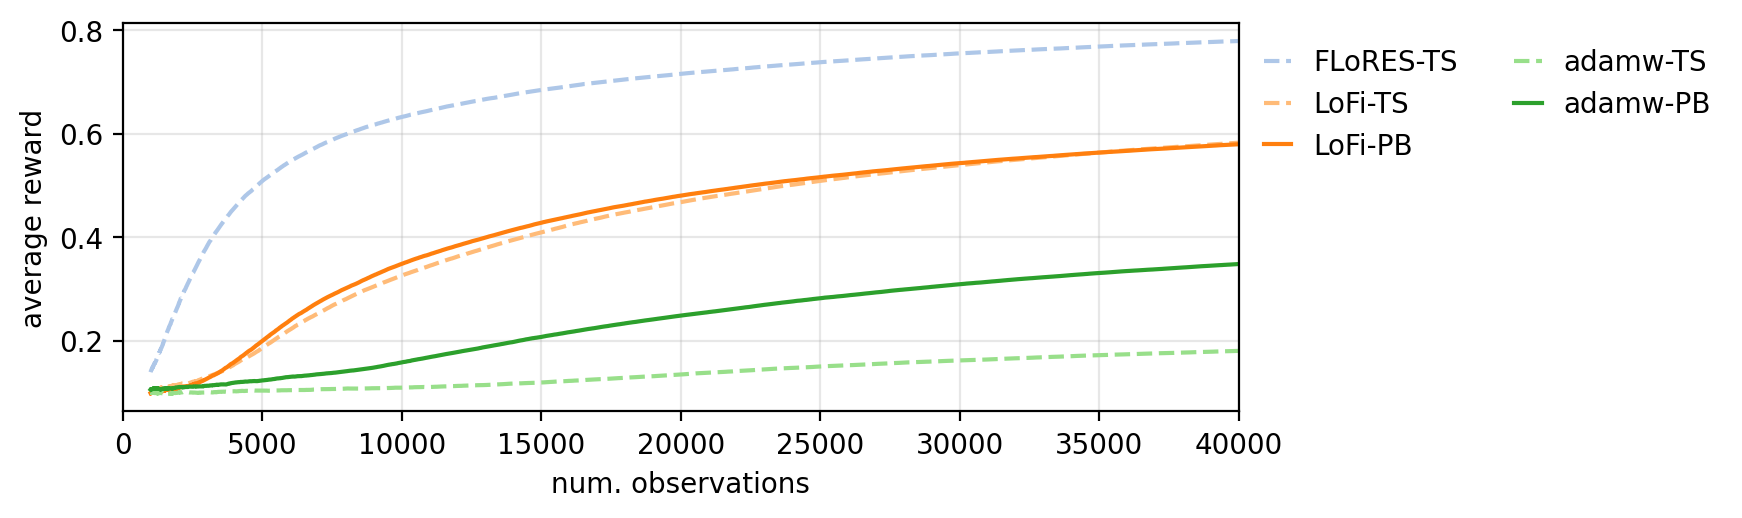

In [83]:
%%time
fig, ax = plt.subplots(figsize=(7.2, 4.2 * 0.6))

res_methods = {}

colors = sns.color_palette("tab20")
hatches = ["x", "o"]
for i, agent in enumerate(sorted(agents)):
    # date = date2 if (agent == "FLoRES") or (agent == "FLoRESLite") else date1
    date = date2 if (agent == "LoFi") or (agent == "adamw") else date1
    agent_path_predictive = f"./output/{agent}_predictive_bayes_{date}.pkl"
    agent_path_ts = f"./output/{agent}_ts_{date}.pkl"
    

    res = pd.read_pickle(agent_path_ts)
    plot_rewards(
        res["rewards"].T, label=f"{agent}-TS", linestyle="--",
        color=colors[2 * i  + 1], hatch=hatches[(2 * i  + 1) % 2]
    )

    res_methods[f"{agent}-ts"] = {
        "reward": res["rewards"].sum(axis=1).mean(),
        "time": res["time"],
        "reward_prop": (res["rewards"].sum(axis=1) / 40_000).mean(),
        "reward_prop_std": (res["rewards"].sum(axis=1) / 40_000).std(),
    }


    if agent == "FLoRES":
        continue
    agent = agent_map[agent]
    res = pd.read_pickle(agent_path_predictive)
    plot_rewards(
        res["rewards"].T, label=rf"{agent}-PB",
        color=colors[2 * i], hatch=hatches[i % 2]
    )

    res_methods[f"{agent}-pBayes"] = {
        "reward": res["rewards"].sum(axis=1).mean(),
        "time": res["time"],
        "reward_prop": (res["rewards"].sum(axis=1) / 40_000).mean(),
        "reward_prop_std": (res["rewards"].sum(axis=1) / 40_000).std(),
    }

    
plt.legend(ncol=2, handlelength=1, bbox_to_anchor=(1,1), frameon=False)
plt.xlabel("num. observations")
plt.ylabel("average reward")
plt.grid(alpha=0.3)
plt.xlim(0, 40_000)
# plt.savefig("../figures/mnist-bandit-reward.png", dpi=300, bbox_inches="tight")

res_methods = pd.DataFrame(res_methods)
res_methods.loc["minutes"] = res_methods.loc["time"] / 60
res_methods = res_methods.rename({
    "reward": "cumulative reward",
}).rename({
    "FLoRES-ts": "HiLoFi-pBayes"
}, axis=1)

In [84]:
table = res_methods.loc[["cumulative reward", "minutes"]].T
table

,cumulative reward,minutes
HiLoFi-pBayes,"31,167.6992",8.4317
LoFi-ts,"23,304.3008",38.9005
LoFi-pBayes,"23,184.5000",4.7625
adamw-ts,"7,201.8999",191.5424
adamw-pBayes,"13,922.2998",1.3602


In [85]:
print(table.to_markdown())

|               |   cumulative reward |   minutes |
|:--------------|--------------------:|----------:|
| HiLoFi-pBayes |             31167.7 |   8.43168 |
| LoFi-ts       |             23304.3 |  38.9005  |
| LoFi-pBayes   |             23184.5 |   4.76253 |
| adamw-ts      |              7201.9 | 191.542   |
| adamw-pBayes  |             13922.3 |   1.36025 |
